In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_blobs

In [3]:
import random

In [4]:
centroid = [(-5,-5),(5,5),(2,-2.5),(-2,2.5)]
cluster_std = [1,1,1,1]

In [5]:
X,y = make_blobs(n_samples = 100 , cluster_std= cluster_std,centers=centroid,n_features=2,random_state=2)

In [6]:
class Kmeans:

    def __init__(self,n_clusters = 2,max_iteration = 100):
        self.n_clusters = n_clusters
        self.max_iteration = max_iteration

    def fit_predict(self,X):
        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroid = X[random_index]

        for i in range(self.max_iteration):

          # Assign Cluster
          cluster_group = self.assign_clusters(X)
          old_centroid = self.centroid

          # Move Centroid
          self.centroid = self.move_centroid(X,cluster_group)

          # Check Finish
          if np.allclose(old_centroid, self.centroid):
            break

        return cluster_group

    def assign_clusters(self,X):
        cluster_group = []
        distance = []

        for row in X:
            for centroid in self.centroid:
                distance.append(np.sqrt(np.dot(row - centroid ,row - centroid)))

            min_distance = min(distance)
            index_pos = distance.index(min_distance)
            cluster_group.append(index_pos)
            distance.clear()

        return np.array(cluster_group)

    def move_centroid(self,X,cluster_group):
        new_centroid = []

        cluster_type = np.unique(cluster_group)

        for i in cluster_type:
            new_centroid.append(X[cluster_group == i].mean(axis=0))

        return np.array(new_centroid)

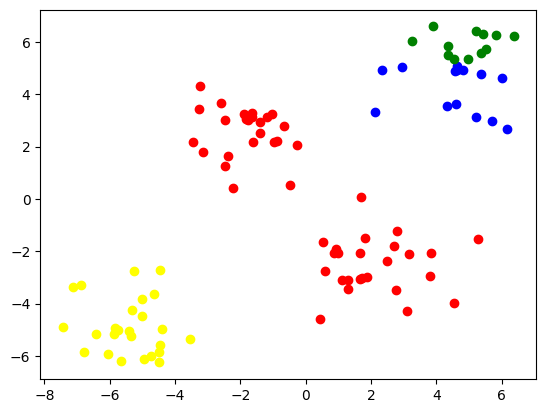

In [7]:
km = Kmeans(4,100)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],c = 'red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],c = 'blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],c = 'yellow')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],c = 'green')
plt.show()